In [270]:
import pandas as pd
import numpy as np

import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score

import matplotlib.pyplot as plt


In [271]:
# Load the data from the CSV file

df_train = pd.read_csv("../data/train_data-cleaned.csv")

# df['price_per_m2'] = df['price'] / df['livingArea']
# postal_code_price = df.groupby('postalCode')['price_per_m2'].mean().round().sort_values(ascending=False)
# df['postalCode'] = df['postalCode'].map(postal_code_price.to_dict())

df_train.drop(columns=['Unnamed: 0'], inplace=True)

#------------------------------------

df_test = pd.read_csv("../data/test_data-cleaned.csv")

# df_test['price_per_m2'] = df_test['price'] / df_test['livingArea']
# postal_code_price = df_test.groupby('postalCode')['price_per_m2'].mean().round().sort_values(ascending=False)
# df_test['postalCode'] = df_test['postalCode'].map(postal_code_price.to_dict())

df_test.drop(columns=['Unnamed: 0'], inplace=True)


print(df_train.shape)
print(df_test.shape)


(47011, 62)
(11753, 62)


In [272]:
df_train['price'].describe()

count    4.701100e+04
mean     4.051629e+05
std      2.545818e+05
min      0.000000e+00
25%      2.400000e+05
50%      3.390000e+05
75%      4.930000e+05
max      1.725000e+06
Name: price, dtype: float64

Prepare for regression + Standardize scales

In [273]:
price_correlations = df_train.corr()['price'].abs().sort_values(ascending=False)
features = price_correlations.index.tolist()[1:]

# Select features with correlation greater than 0.1
features = [col for col in price_correlations.index.tolist()[1:] if price_correlations[col] > 0.01]
print(f"Selected {len(features)} features with correlation > 0.01")

target = 'price'

x_train = df_train[features]
y_train = df_train[target]

# Split the dataset
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_test = df_test[features]
y_test = df_test[target]

Selected 56 features with correlation > 0.01


---
## Option 1: Linear Regression Coefficients (for linear relationships)

<Axes: title={'center': 'Linear Regression Feature Importance'}>

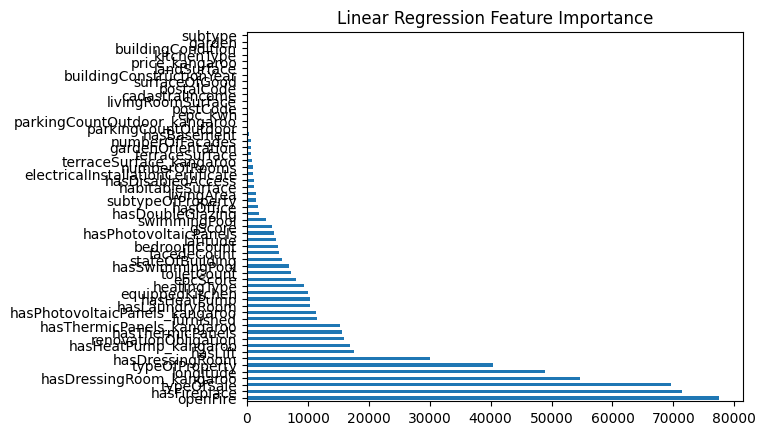

In [274]:
lr = LinearRegression()
lr.fit(x_train, y_train)

# Get importance from coefficients (absolute values give relative importance)
importance = pd.Series(np.abs(lr.coef_), index=features)
importance.sort_values(ascending=False).plot(kind='barh', title='Linear Regression Feature Importance')

## Evaluate Model

In [275]:
y_pred = lr.predict(x_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("MAPE:", np.mean(np.abs((y_test - y_pred) / y_test)) * 100, "%")
print("MAE:", np.mean(np.abs(y_test - y_pred)))

RMSE: 163076.7472987614
R² Score: 0.5891105224938429
MAPE: inf %
MAE: 90630.51011636258


---

## Option 2: XGBoost
XGBoost (eXtreme Gradient Boosting) is another powerful ensemble learning technique that often outperforms both linear regression and random forest models. It uses gradient boosting with regularization to reduce overfitting and improve performance.

Key advantages of XGBoost:
- High performance and efficient computation
- Regularization to prevent overfitting
- Handles missing values automatically
- Supports parallel processing
- Offers built-in cross-validation

For our housing price prediction task, XGBoost can capture complex non-linear relationships while maintaining good generalization performance.

<Axes: title={'center': 'XGBoost Feature Importance'}>

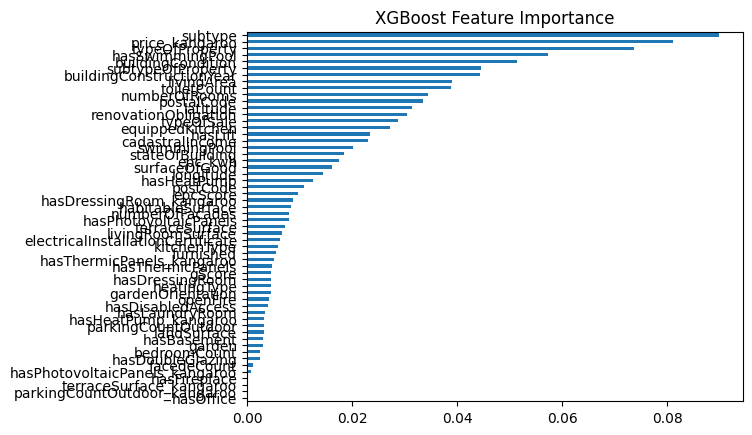

In [276]:

# Initialize XGBoost model with good default parameters
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.2,
    max_depth=7,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=0.6,
    objective='reg:squarederror',
    random_state=42
)

# # Finetuning with GridSearchCV,
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0],
#     'min_child_weight': [1, 3, 5]
# }
# grid_search = GridSearchCV(
#     estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )
# grid_search.fit(x_train, y_train)
# best_params = grid_search.best_params_
# print(f"Best parameters: {best_params}")
# xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)

# Train the model
xgb_model.fit(x_train, y_train)

# Get feature importance
importance = pd.Series(xgb_model.feature_importances_, index=features)
importance.sort_values(ascending=True).plot(
    kind='barh', 
    title='XGBoost Feature Importance'
)

### Evaluate Model

In [277]:
# Make predictions
y_pred = xgb_model.predict(x_test)

# Evaluate the model
print("XGBoost Performance Metrics:")
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred) * 100, "%")
print("MAE:", mean_absolute_error(y_test, y_pred))



XGBoost Performance Metrics:
RMSE: 83436.5703125
R² Score: 0.8924392461776733
MAPE: 4.596131777185055e+19 %
MAE: 37213.15234375
